# Volatility and Risk Analysis 

In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# let us establish a dataframe and a connection to a database
conn1 = sqlite3.connect('..\db\walmart.db')
df1 = pd.read_sql('SELECT * FROM walmart_sales',conn1)
conn1.close()
conn = sqlite3.connect('..\db\walmart.db')

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
C:\Users\david\AppData\Local\Temp\ipykernel_39024\3549601277.py:2: SyntaxWarning: invalid escape sequence '\d'
  conn1 = sqlite3.connect('..\db\walmart.db')
C:\Users\david\AppData\Local\Temp\ipykernel_39024\3549601277.py:5: SyntaxWarning: invalid escape sequence '\d'
  conn = sqlite3.connect('..\db\walmart.db')


## Objective 
The objective of this phase is to assess the stability and risk characteristics of Walmart store performance by analysing sales variability and downside risk over time.
While earlier phases focused on performance and momentum, this section evaluates how consistent and reliable those sales trends are.

## KPI 1: Store-Level Sales Volatility


### Business Question
Which stores exhibit the highest sales volatility, and how variability differ across locations?

### Metric Definition

__Weekly Sales Mean (Average_Weekly_Sales)__: Measures average sales in weekly sales

__Standard Deviation (STD)__: Measures absolute variability in weekly sales

__Coefficient of Variation (CV)__: Normalizes volatility relative to average sales, allowing fair comparison across stores

In [3]:
pd.read_sql(
    """
WITH walmart_stats as (
SELECT
    Store,
    AVG(Weekly_Sales) as Average_Weekly_Sales,
    ROUND(SQRT(AVG(Weekly_Sales * Weekly_Sales) - AVG(Weekly_Sales) * AVG(Weekly_Sales)),2) as STD_Weekly_Sales
FROM walmart_sales
GROUP BY Store)
SELECT
    STORE,
    Average_Weekly_Sales,
    STD_Weekly_Sales,
    ROUND(STD_Weekly_Sales/Average_Weekly_Sales,2) AS CV
FROM walmart_stats
ORDER BY CV DESC
LIMIT 10""",
conn
)

,Store,Average_Weekly_Sales,STD_Weekly_Sales,CV
0,3,6373.033983,14250.25,2.24
1,44,6038.929814,10608.73,1.76
2,38,7492.478460,12732.49,1.70
3,30,8764.237719,14363.31,1.64
4,5,5053.415813,8067.77,1.60
5,42,11443.370118,18257.22,1.60
6,37,10297.355026,16294.36,1.58
7,33,5728.414053,8973.00,1.57
8,43,13415.114118,20809.37,1.55
9,36,8584.412563,12994.77,1.51


### Insight
While most stores exhibita sales stability near ~ 1.0, a considerable subset shows disproportionately high votality with CV scores of 1.5+ including an concerning CV score of 2.24. These stores introduce forecasting and staffing risk despite their average weekly sales contributing less to the total sales. This suggests operational inefficiencies than growth opportunities.

## KPI 2: Downside Risk — Frequency of Sales Declines

## Business Question

Which stores experience the most frequent week-over-week sales declines?

### Metric Definition

__Downside Risk__: Percentage of weeks where week-over-week sales growth is negative

This captures risk exposure, not just volatility magnitude

In [4]:
decline_df =pd.read_sql("""
WITH weekly_store_sales AS (
SELECT 
    DATE(Date) AS Date,
    Store,
    SUM(Weekly_Sales) as Total_Weekly_Sales
FROM walmart_sales
GROUP BY Store, Date
),
store_wow AS (
SELECT
    Date,
    Store,
    Total_Weekly_Sales,
    LAG(Total_Weekly_Sales) OVER (
            PARTITION BY Store
            ORDER BY Date
            ) AS Prev_Weekly_Sales
FROM weekly_store_sales
),
wow_percent_change AS(
SELECT
    Date,
    Store,
    Total_Weekly_Sales,
    Prev_Weekly_Sales,
    ROUND(
            (Total_Weekly_Sales - Prev_Weekly_Sales)
            /NULLIF(Prev_Weekly_Sales,0)*100,2) as WoW_Change
FROM store_wow
WHERE Prev_Weekly_Sales IS NOT NULL)
SELECT
    Store,
    COUNT(*) AS Decline_Sales_Count
FROM wow_percent_change
WHERE WoW_Change <0
GROUP BY Store
ORDER BY Decline_Sales_Count DESC

""",
conn)
decline_df.head(10)

,Store,Decline_Sales_Count
0,28,86
1,42,85
2,38,82
3,20,82
4,2,80
5,1,80
6,11,79
7,7,78
8,3,78
9,34,77


## Insight
Out of the 143-week timeframe, these stores experienced week-over-week declines in total sales for more than half of the observed periods. This indicates elevated sales volatility and inconsistent customer demand, suggesting higher operational and revenue risk relative to other stores.out the year.

## KPI 3: Volatility vs Performance Tradeoff
### Business Question

Do the highest-performing stores also carry higher sales risk?

__Analytical Approach__

Compare average weekly sales against coefficient of variation

__Identify stores that combine__:

High performance & low volatility (ideal)

High performance & high volatility (risky)

In [5]:
df =df1[['Date','Weekly_Sales','Dept','Store','IsHoliday']]
df['Total_Weekly_Sales'] =(
    df.groupby(['Date','Store'])['Weekly_Sales']
    .transform('sum')
)
kpi3 = (
    df
    .groupby('Store')
    .agg(
        Avg_Weekly_Sales=('Total_Weekly_Sales','mean'),
        STD_Weekly_Sales = ('Total_Weekly_Sales','std')
    )
)
kpi3['CV'] = kpi3['STD_Weekly_Sales'] / kpi3['Avg_Weekly_Sales']
avg_sales_median = kpi3['Avg_Weekly_Sales'].median()
CV_median = kpi3['CV'].median()

C:\Users\david\AppData\Local\Temp\ipykernel_39024\200451066.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Total_Weekly_Sales'] =(


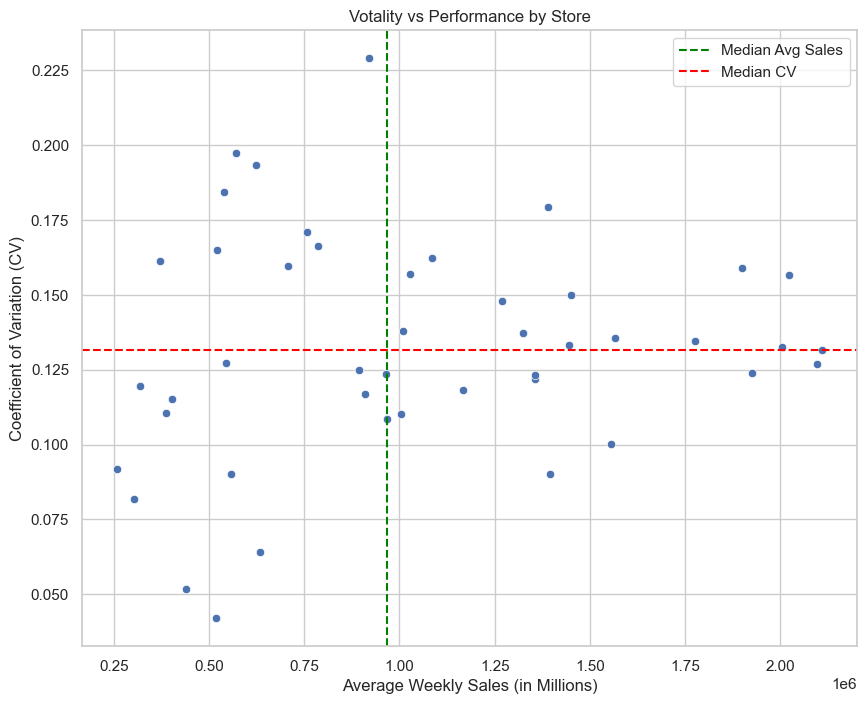

In [6]:
sns.set(style= 'whitegrid')

plt.figure(figsize=(10,8))

sns.scatterplot(
    data = kpi3,
    x ='Avg_Weekly_Sales',
    y = 'CV'
)
plt.axvline(avg_sales_median,
            linestyle ='--',
            color ='green',
            label ='Median Avg Sales')
plt.axhline(CV_median, 
            linestyle = '--',
            color ='red',
            label ='Median CV')

plt.title('Votality vs Performance by Store')
plt.xlabel('Average Weekly Sales (in Millions)')
plt.ylabel('Coefficient of Variation (CV)')
plt.legend(loc ='upper right')
plt.show()

### Insight

The distribution highlights a clear performance–risk tradeoff across stores.  
Stores in the **fourth quadrant** represent high-performing, low-volatility locations, making them the most operationally efficient and predictable.  

In contrast, stores in the **first quadrant** also generate strong average weekly sales but exhibit elevated volatility, indicating higher operational risk despite strong revenue performance.  

Overall, the spread of points on the right side of the chart suggests that high sales do not guarantee stability, reinforcing the need to evaluate performance and risk jointly rather than in isolation.


## Exporting Tables

Let us prep our tables so we can feed it into PowerBI

In [7]:
total_sales =(
    df
    .groupby('Store')['Weekly_Sales']
    .sum()
    .reset_index(name ='Total_Sales')
)
#adding the kpi3 and total_sales table
store_summary = (
    kpi3
    .reset_index()
    .merge(total_sales, on ='Store', how ='left')
)
#adding the decline sales df
store_summary =(
    store_summary
    .merge(decline_df, on ='Store', how ='left')
)
store_summary

store_summary = store_summary[['Store','Total_Sales','Avg_Weekly_Sales','STD_Weekly_Sales','CV', 'Decline_Sales_Count']]
store_summary.head()

,Store,Total_Sales,Avg_Weekly_Sales,STD_Weekly_Sales,CV,Decline_Sales_Count
0,1,2.224028e+08,1.555795e+06,156031.394350,0.100290,80
1,2,2.753824e+08,1.926818e+06,238698.748076,0.123882,80
2,3,5.758674e+07,4.030476e+05,46405.695032,0.115137,78
3,4,2.995440e+08,2.095075e+06,265591.469067,0.126769,66
4,5,4.547569e+07,3.183279e+05,38052.255525,0.119538,69


In [8]:
#FINAL STORE LEVEL KPI TABLE
#Schema frozen and ready for POWERBI use
store_summary.to_csv(
    '../data/processed/store_summary.csv',
    index= False
)